In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set visual style for all graphs
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

print("Libraries imported successfully!")

Libraries imported successfully!


In [11]:
# Reading the exact file name you uploaded to Colab
dataframe = pd.read_csv("Zomato data .csv")
print("\n--- Data successfully loaded! Here are the first 5 rows: ---")
display(dataframe.head())


--- Data successfully loaded! Here are the first 5 rows: ---


,name,online_order,book_table,rate,votes,approx_cost(for two people),listed_in(type)
0,Jalsa,Yes,Yes,4.1/5,775,800,Buffet
1,Spice Elephant,Yes,No,4.1/5,787,800,Buffet
2,San Churro Cafe,Yes,No,3.8/5,918,800,Buffet
3,Addhuri Udupi Bhojana,No,No,3.7/5,88,300,Buffet
4,Grand Village,No,No,3.8/5,166,600,Buffet


In [12]:
# Function to clean the 'rate' column (e.g., converting '4.1/5' to 4.1)
def handleRate(value):
    if pd.isna(value):
        return np.nan
    value = str(value).split("/")
    value = value[0].strip()
    try:
        return float(value)
    except ValueError:
        return np.nan

# Apply the cleaning function
dataframe["rate"] = dataframe["rate"].apply(handleRate)

# Ensure correct data types for math/plotting
dataframe["votes"] = dataframe["votes"].astype(int)
dataframe["approx_cost(for two people)"] = dataframe["approx_cost(for two people)"].astype(float)

print("\n--- Data Cleaning Complete! ---")


--- Data Cleaning Complete! ---


/tmp/ipykernel_3904/3848582263.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


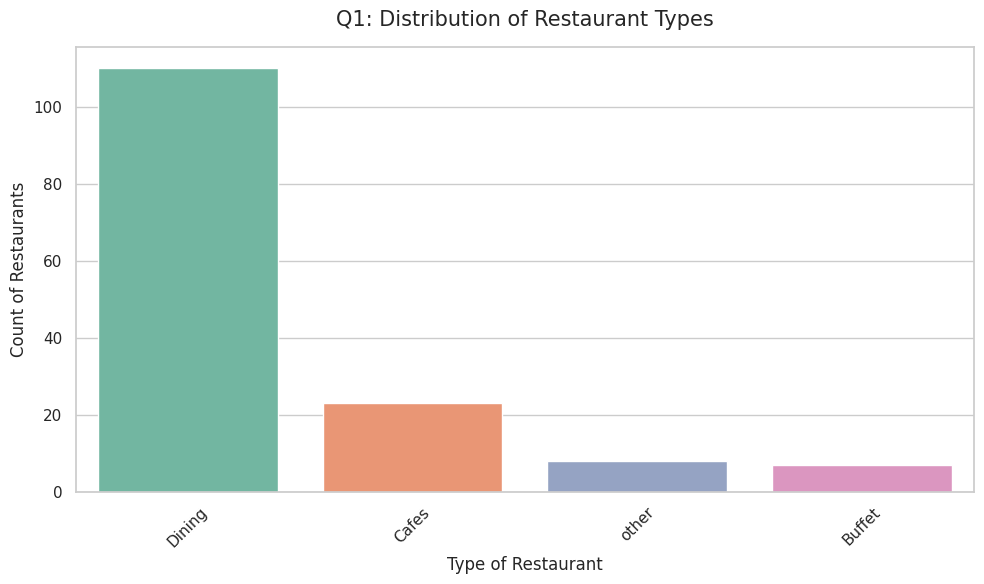

In [13]:
# Q1: What type of restaurant do the majority of customers order from?
plt.figure()
sns.countplot(
    x="listed_in(type)",
    data=dataframe,
    order=dataframe["listed_in(type)"].value_counts().index,
    palette="Set2",
)
plt.title("Q1: Distribution of Restaurant Types", fontsize=15, pad=15)
plt.xlabel("Type of Restaurant", fontsize=12)
plt.ylabel("Count of Restaurants", fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

/tmp/ipykernel_3904/3934245055.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


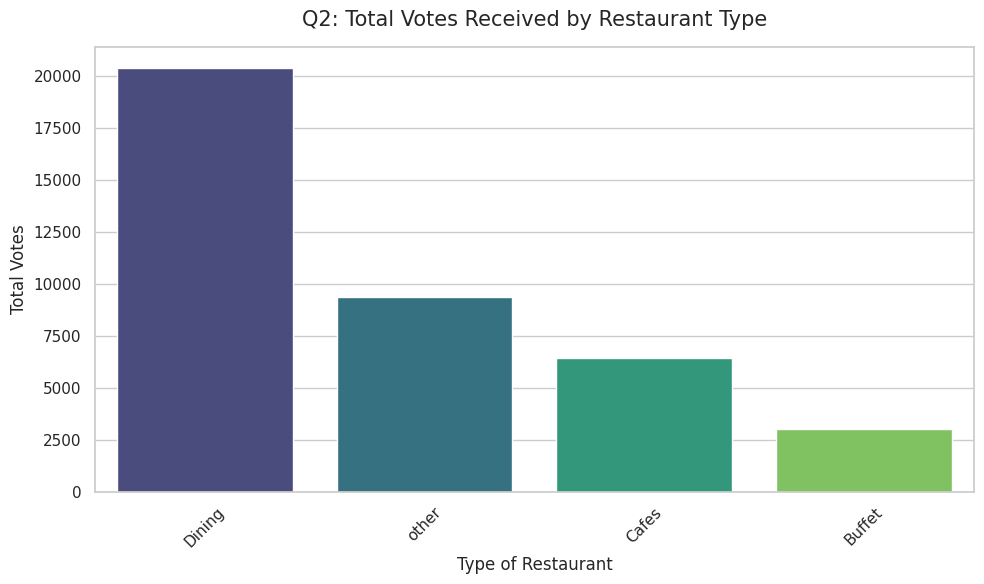

In [14]:
# Q2: How many votes has each type of restaurant received?
plt.figure()
grouped_votes = dataframe.groupby("listed_in(type)")["votes"].sum().reset_index()
grouped_votes = grouped_votes.sort_values(by="votes", ascending=False)

sns.barplot(
    x="listed_in(type)", y="votes", data=grouped_votes, palette="viridis"
)
plt.title("Q2: Total Votes Received by Restaurant Type", fontsize=15, pad=15)
plt.xlabel("Type of Restaurant", fontsize=12)
plt.ylabel("Total Votes", fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

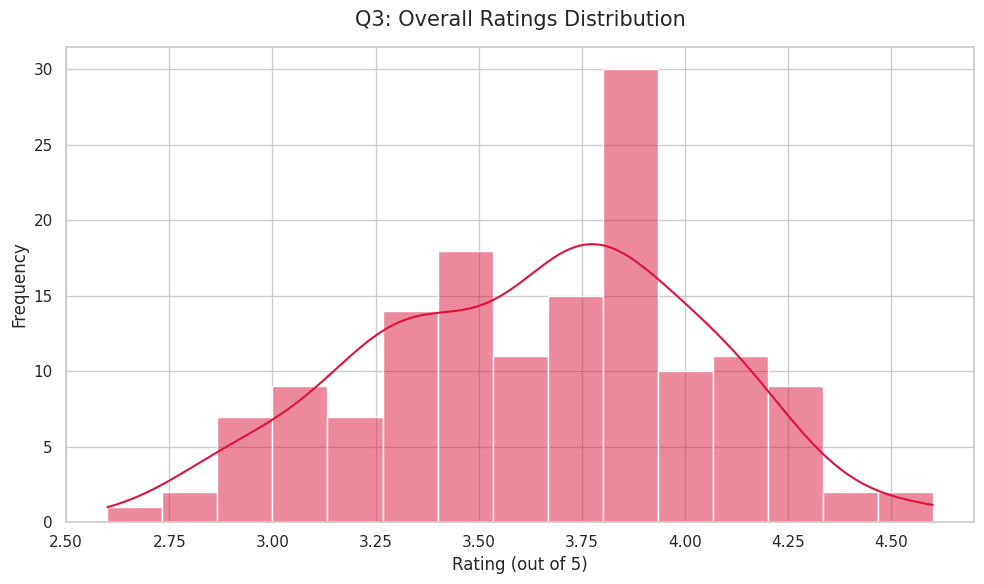

In [15]:
# Q3: What are the ratings that the majority of restaurants received?
plt.figure()
sns.histplot(dataframe["rate"], bins=15, kde=True, color="crimson")
plt.title("Q3: Overall Ratings Distribution", fontsize=15, pad=15)
plt.xlabel("Rating (out of 5)", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.tight_layout()
plt.show()

/tmp/ipykernel_3904/200486561.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


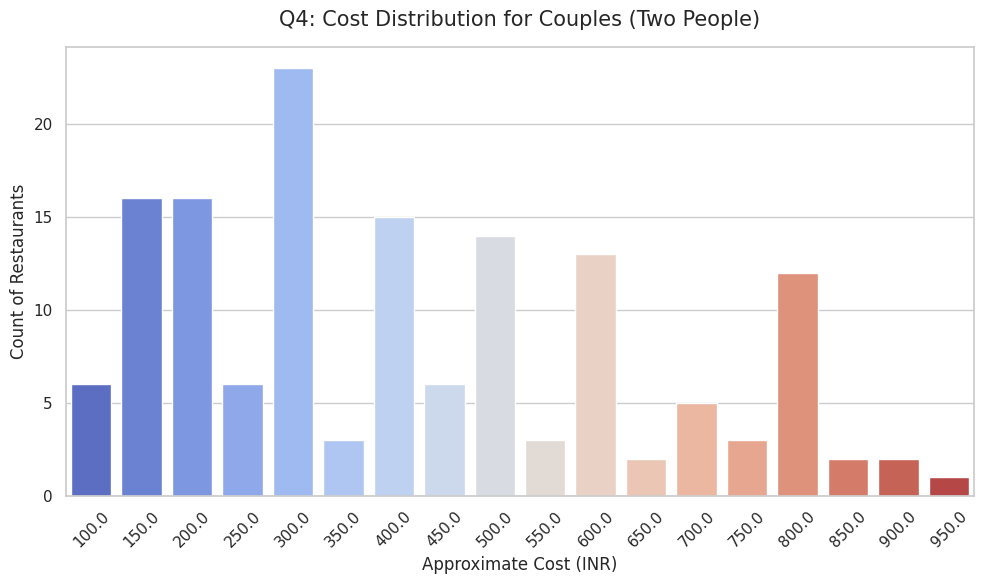

In [16]:
# Q4: Average spending for couples (approx_cost for two)
plt.figure()
sns.countplot(
    x="approx_cost(for two people)", data=dataframe, palette="coolwarm"
)
plt.title("Q4: Cost Distribution for Couples (Two People)", fontsize=15, pad=15)
plt.xlabel("Approximate Cost (INR)", fontsize=12)
plt.ylabel("Count of Restaurants", fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

/tmp/ipykernel_3904/2966732645.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="online_order", y="rate", data=dataframe, palette="Pastel1")


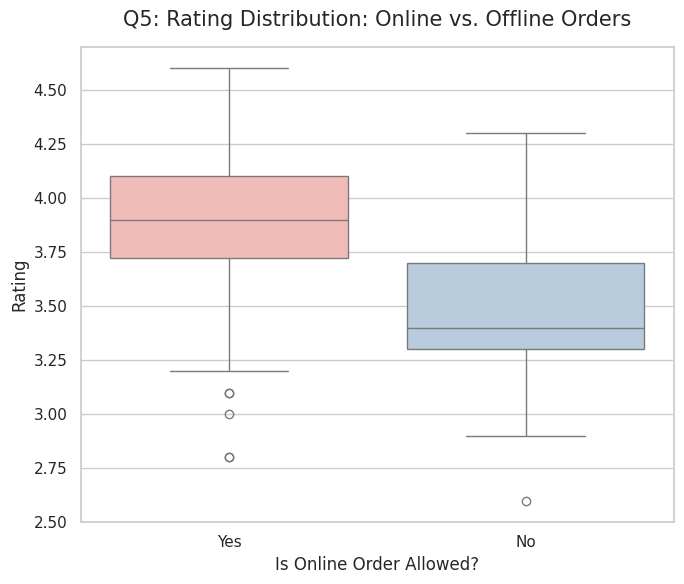

In [17]:
# Q5: Which mode (online vs offline) received maximum ratings?
plt.figure(figsize=(7, 6))
sns.boxplot(x="online_order", y="rate", data=dataframe, palette="Pastel1")
plt.title("Q5: Rating Distribution: Online vs. Offline Orders", fontsize=15, pad=15)
plt.xlabel("Is Online Order Allowed?", fontsize=12)
plt.ylabel("Rating", fontsize=12)
plt.tight_layout()
plt.show()

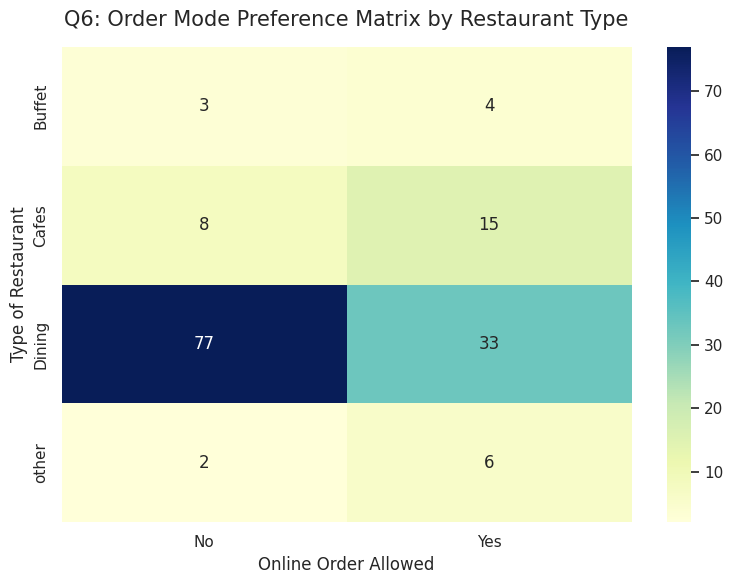

In [18]:
# Q6: Which restaurant type receives more offline vs online orders?
plt.figure(figsize=(8, 6))
pivot_table = dataframe.pivot_table(
    index="listed_in(type)",
    columns="online_order",
    aggfunc="size",
    fill_value=0,
)
sns.heatmap(pivot_table, annot=True, cmap="YlGnBu", fmt="d", cbar=True)
plt.title("Q6: Order Mode Preference Matrix by Restaurant Type", fontsize=15, pad=15)
plt.xlabel("Online Order Allowed", fontsize=12)
plt.ylabel("Type of Restaurant", fontsize=12)
plt.tight_layout()
plt.show()